# 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ids2017/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
/kaggle/input/ids2017/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
/kaggle/input/ids2017/Tuesday-WorkingHours.pcap_ISCX.csv
/kaggle/input/ids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
/kaggle/input/ids2017/Monday-WorkingHours.pcap_ISCX.csv
/kaggle/input/ids2017/Friday-WorkingHours-Morning.pcap_ISCX.csv
/kaggle/input/ids2017/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
/kaggle/input/ids2017/Wednesday-workingHours.pcap_ISCX.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

In [4]:
csv_files = [
"/kaggle/input/ids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
"/kaggle/input/ids2017/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
"/kaggle/input/ids2017/Friday-WorkingHours-Morning.pcap_ISCX.csv",
"/kaggle/input/ids2017/Monday-WorkingHours.pcap_ISCX.csv",
"/kaggle/input/ids2017/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
"/kaggle/input/ids2017/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
"/kaggle/input/ids2017/Tuesday-WorkingHours.pcap_ISCX.csv",
"/kaggle/input/ids2017/Wednesday-workingHours.pcap_ISCX.csv"
]

In [5]:
dfs = [pd.read_csv(file) for file in csv_files]

# Check column consistency
for i, df in enumerate(dfs):
    print(f"{csv_files[i]}: {len(df.columns)} columns")

# 📌 Step 3: Combine into a single DataFrame
data = pd.concat(dfs, ignore_index=True)
print(f"Combined dataset shape: {data.shape}")

# Quick look at the data
print(data.head())
print(data[' Label'].value_counts())

# 📌 Step 4: Encode Labels
# Create binary label for Stage 1: Attack (1) vs Benign (0)
data[' Attack'] = data[' Label'].apply(lambda x: 0 if 'Benign' in str(x) else 1)

# Optional: Multi-class encoding for Stage 2
le = LabelEncoder()
data[' Label_encoded'] = le.fit_transform(data[' Label'])

/kaggle/input/ids2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 79 columns
/kaggle/input/ids2017/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 79 columns
/kaggle/input/ids2017/Friday-WorkingHours-Morning.pcap_ISCX.csv: 79 columns
/kaggle/input/ids2017/Monday-WorkingHours.pcap_ISCX.csv: 79 columns
/kaggle/input/ids2017/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 79 columns
/kaggle/input/ids2017/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 79 columns
/kaggle/input/ids2017/Tuesday-WorkingHours.pcap_ISCX.csv: 79 columns
/kaggle/input/ids2017/Wednesday-workingHours.pcap_ISCX.csv: 79 columns
Combined dataset shape: (2830743, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0              54865               3                   2   
1              55054             109                   1   
2              55055              52                   1   
3              46236              34                   1   
4              54863     

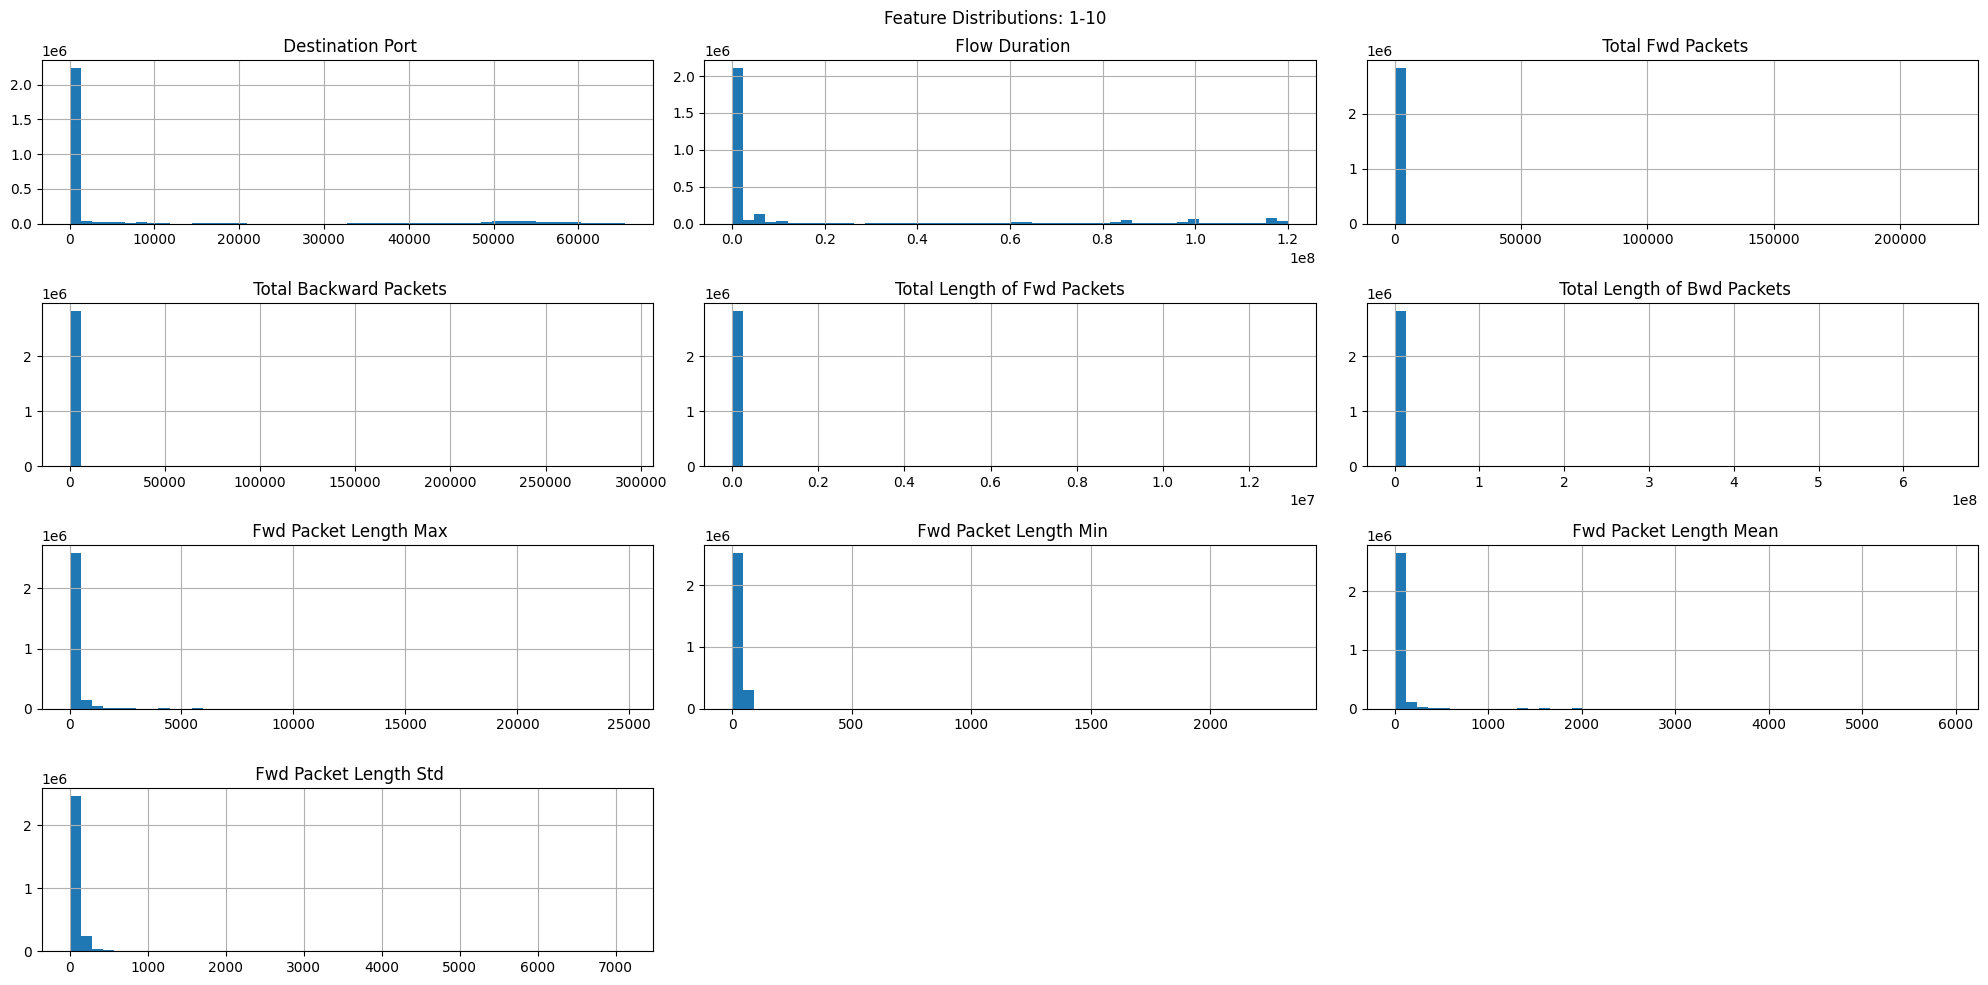

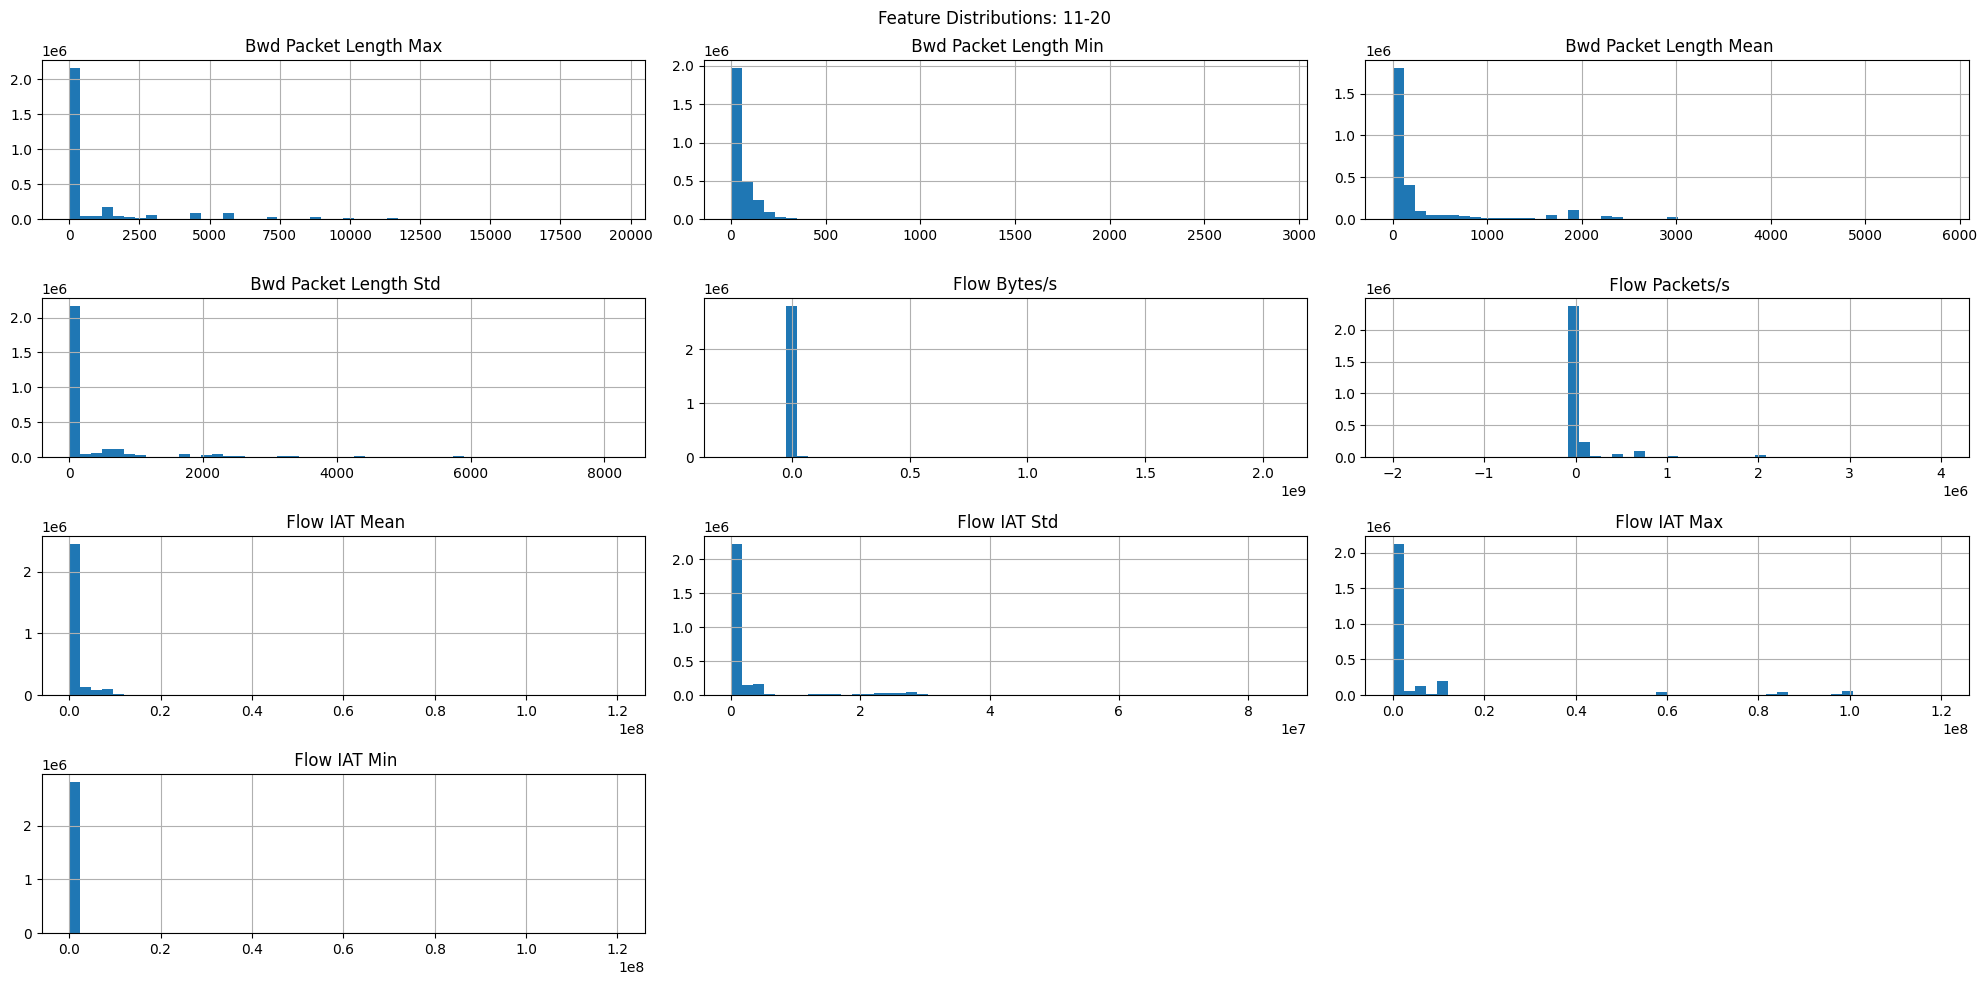

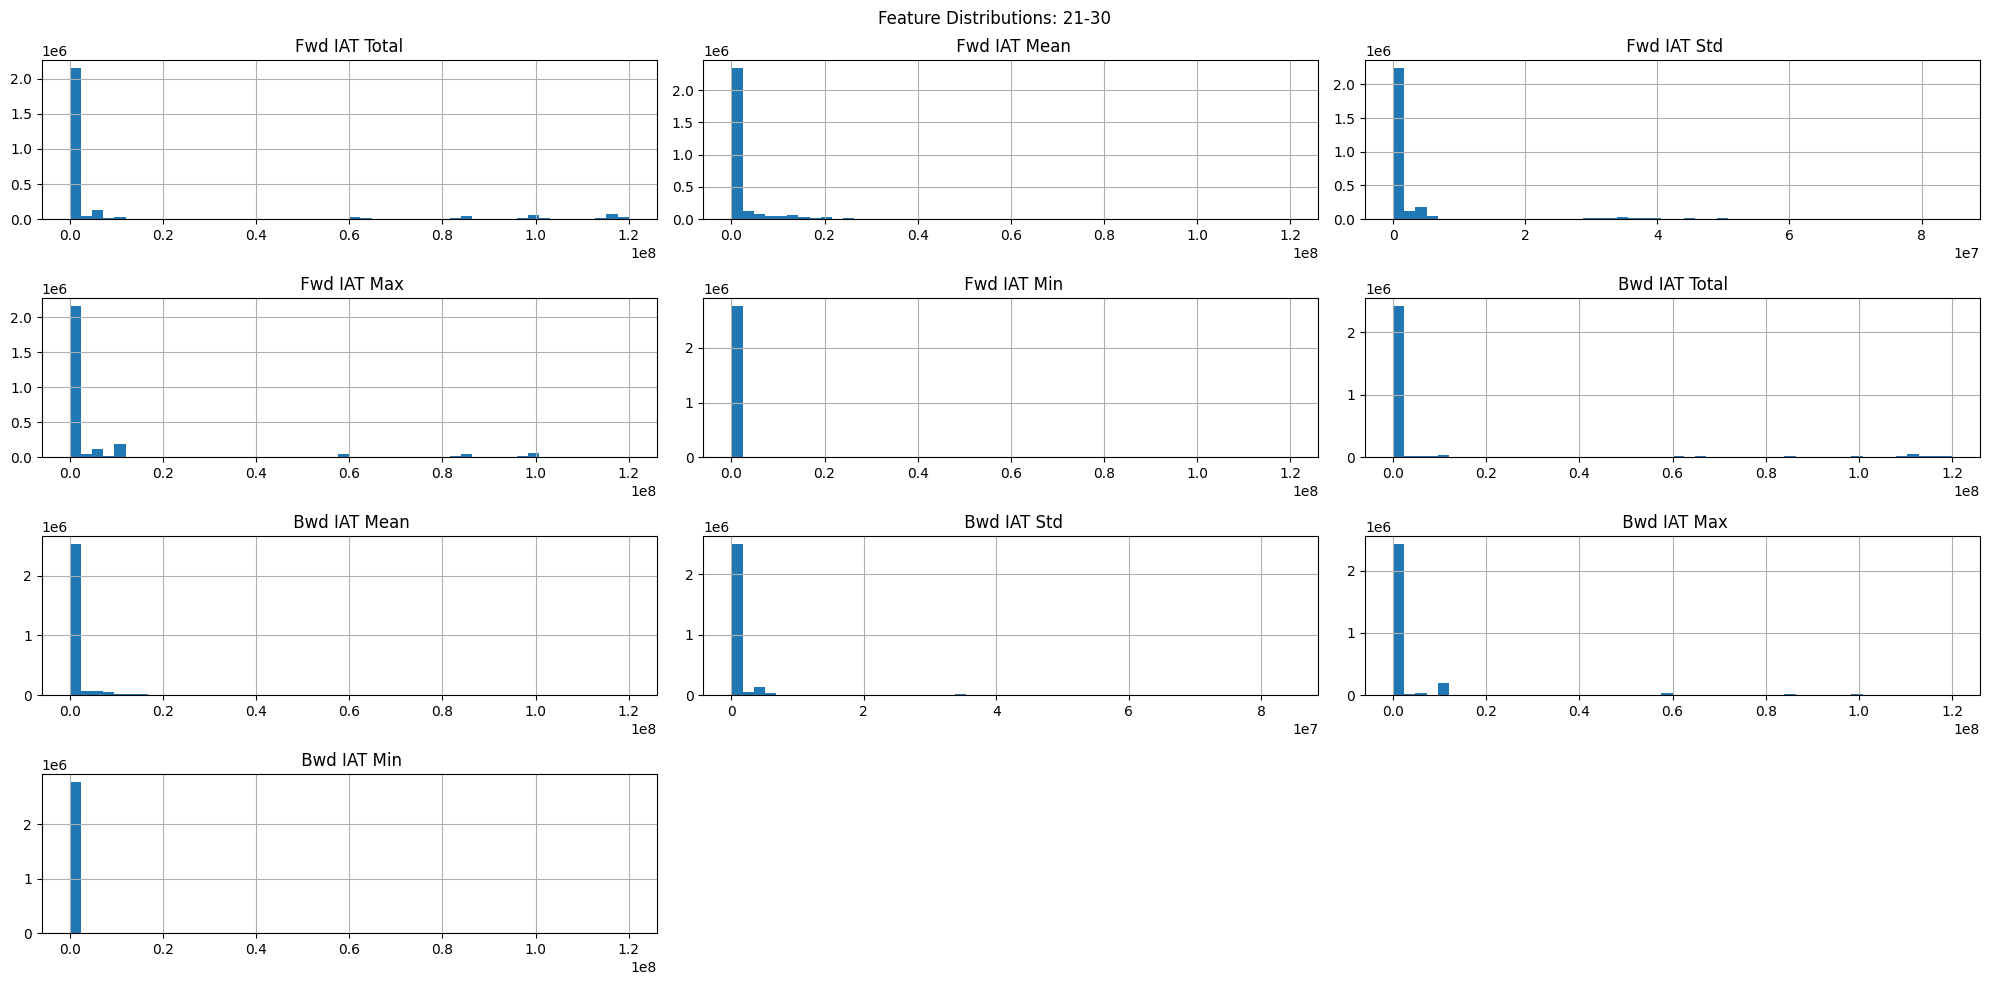

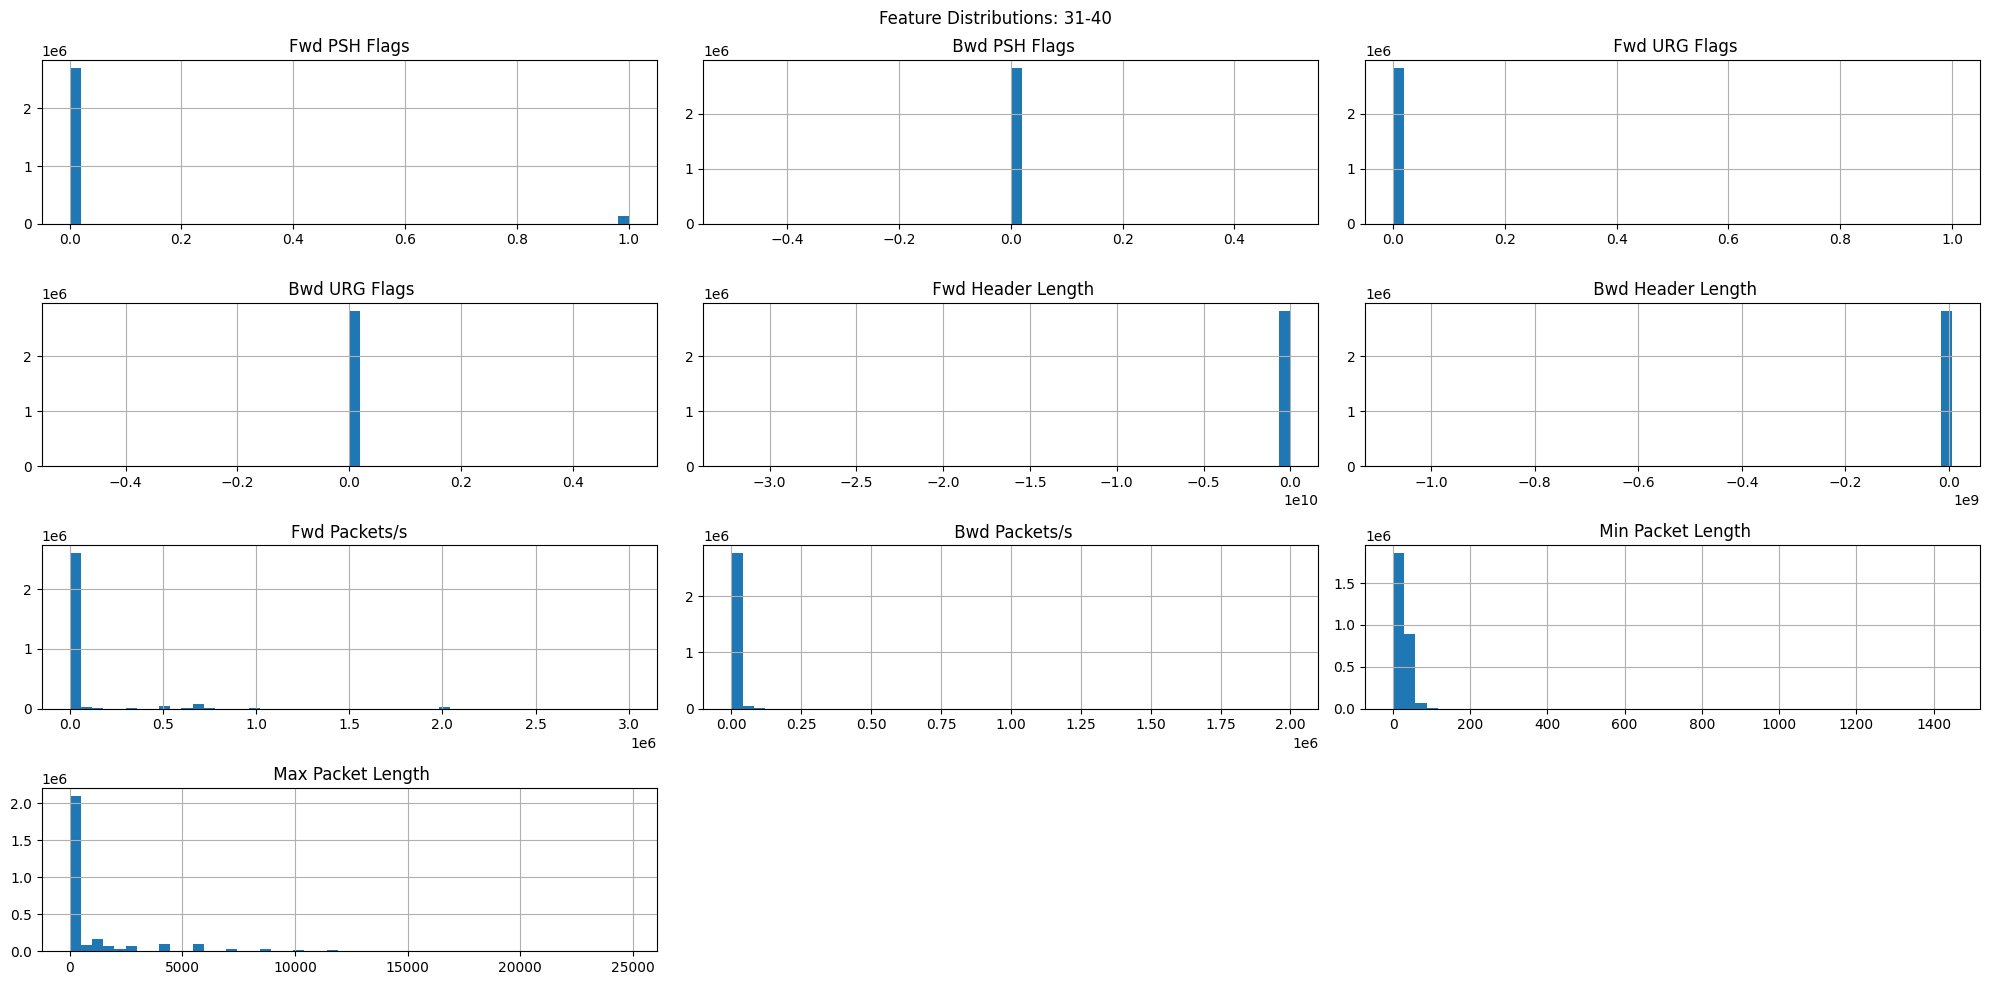

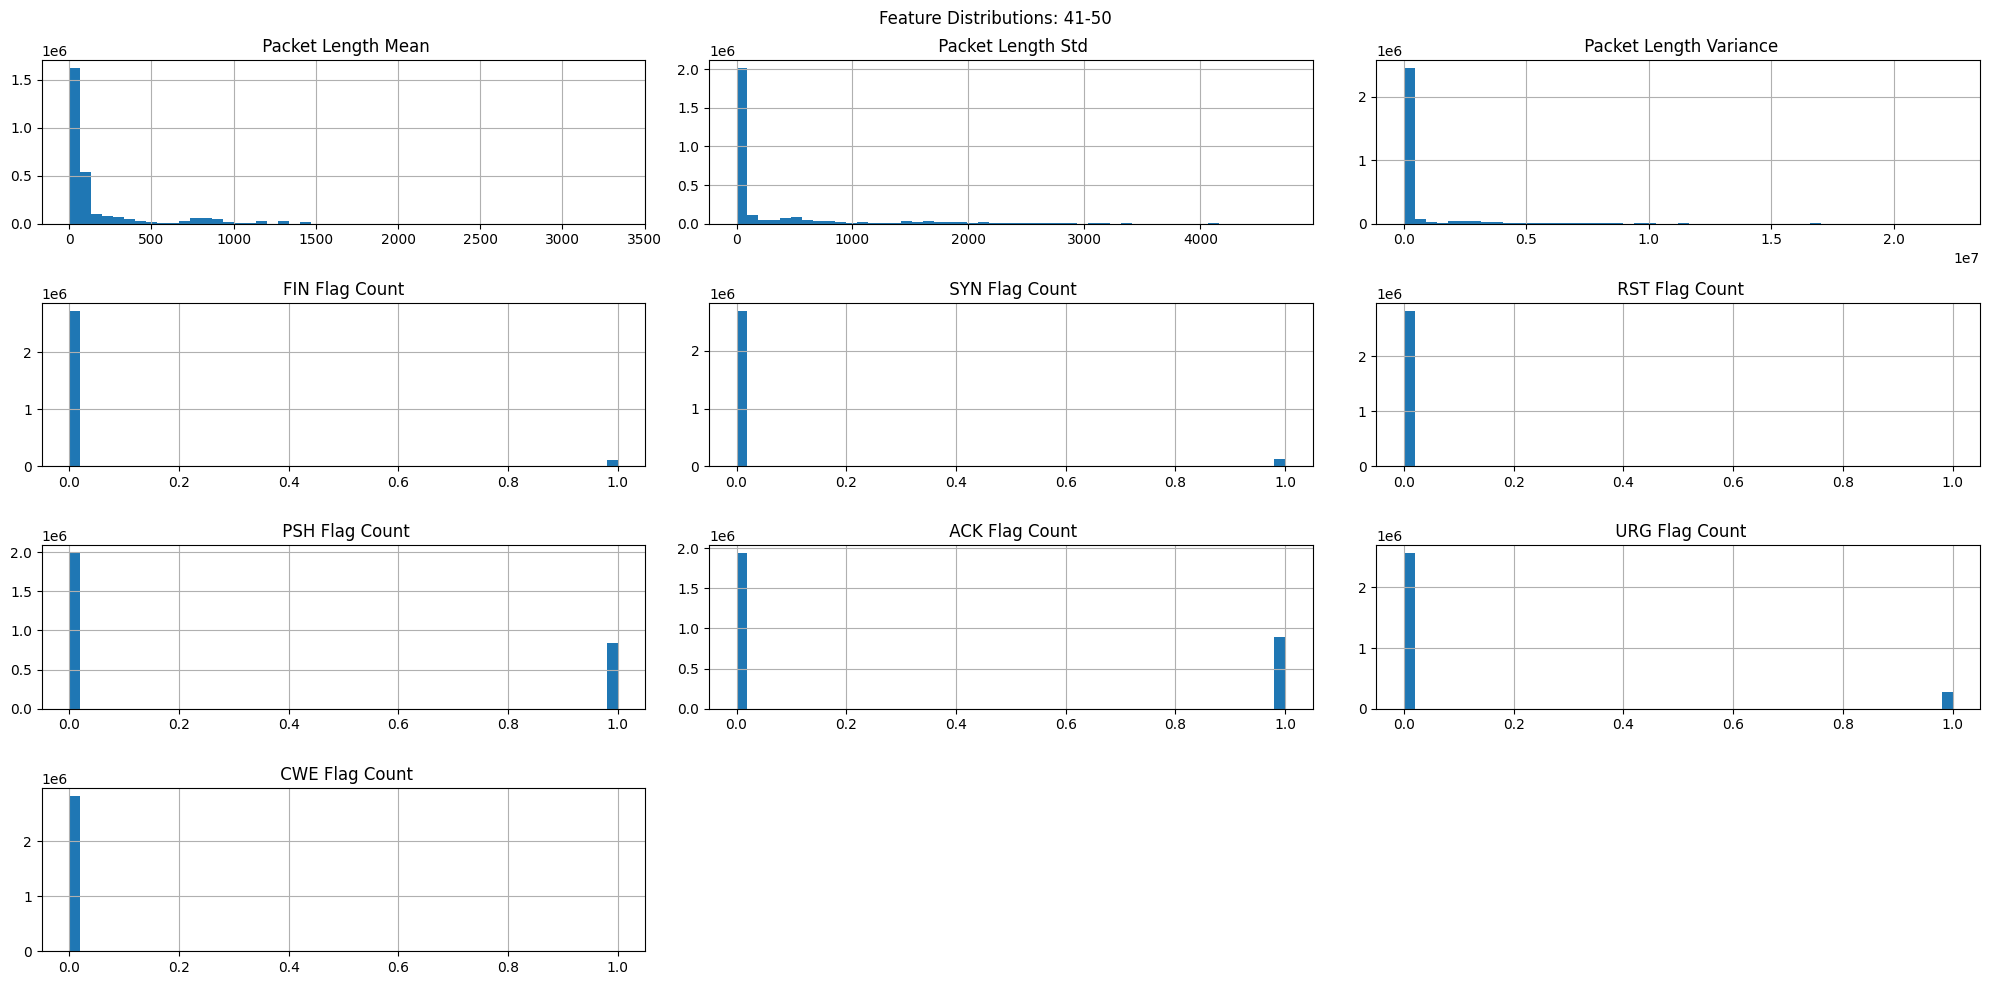

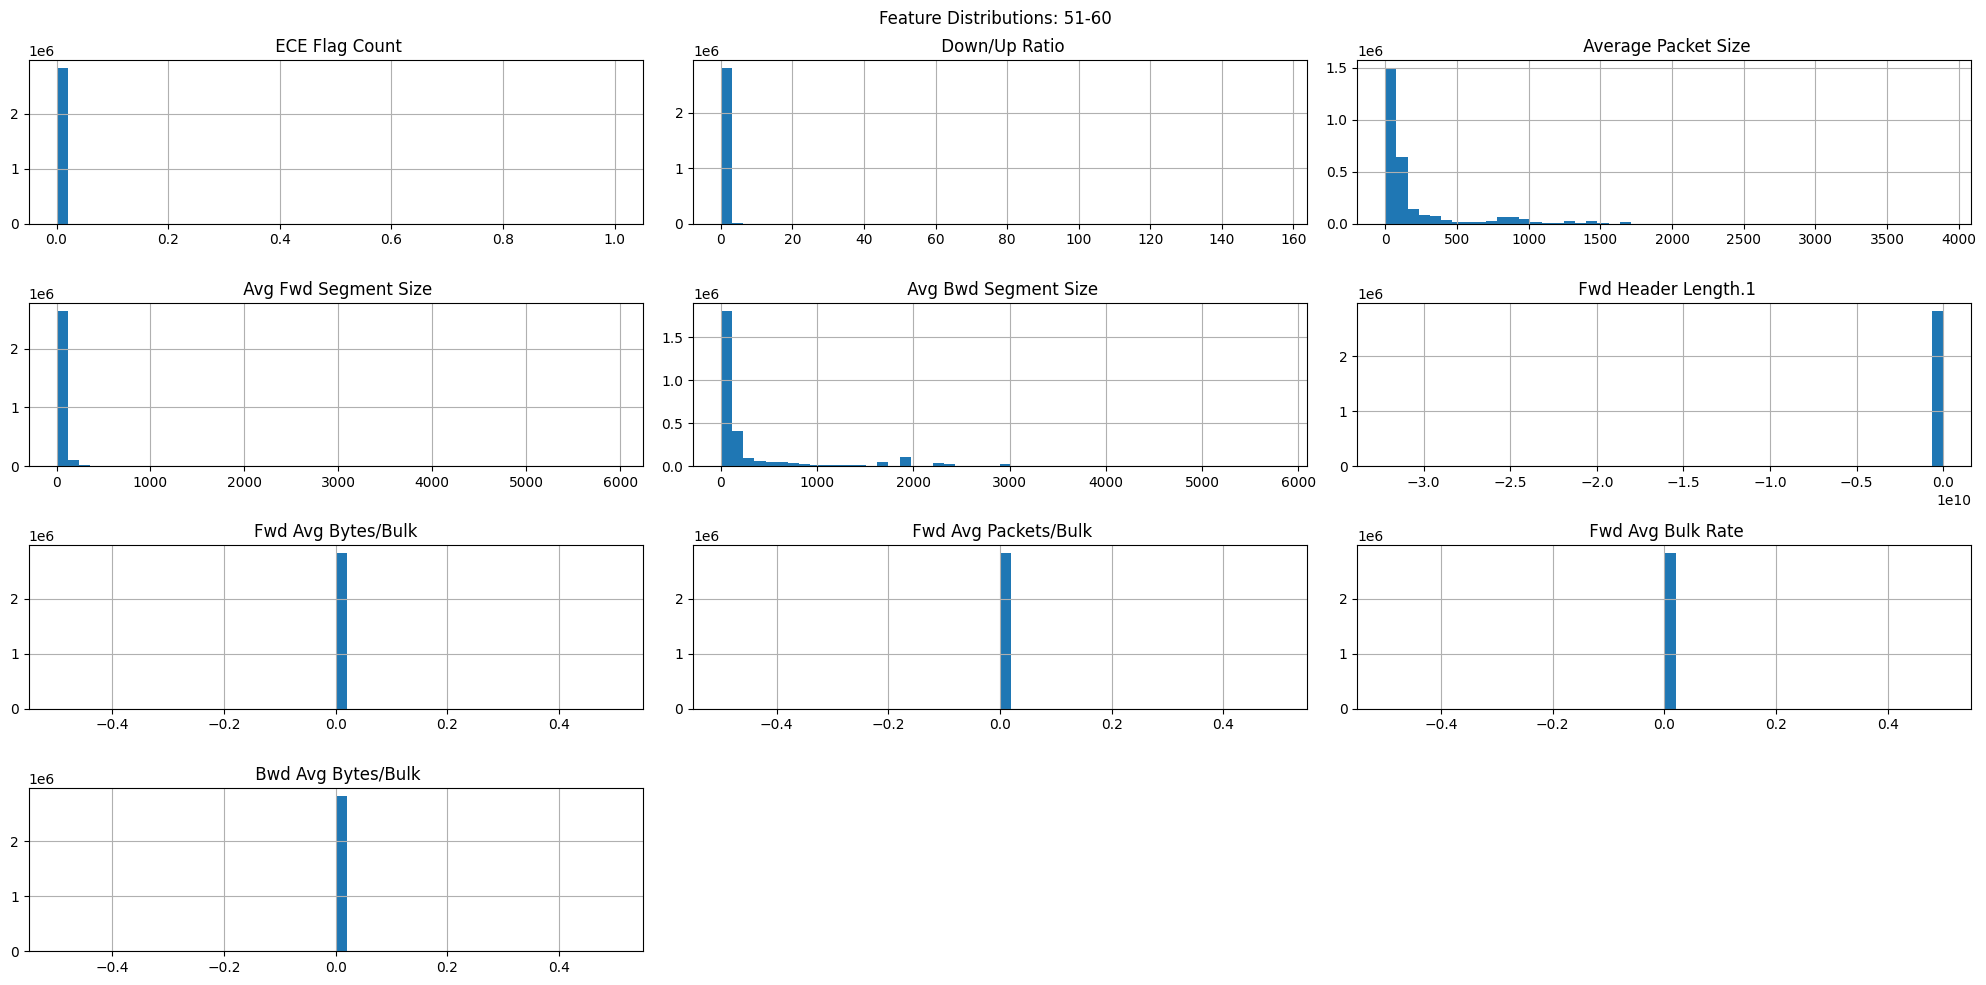

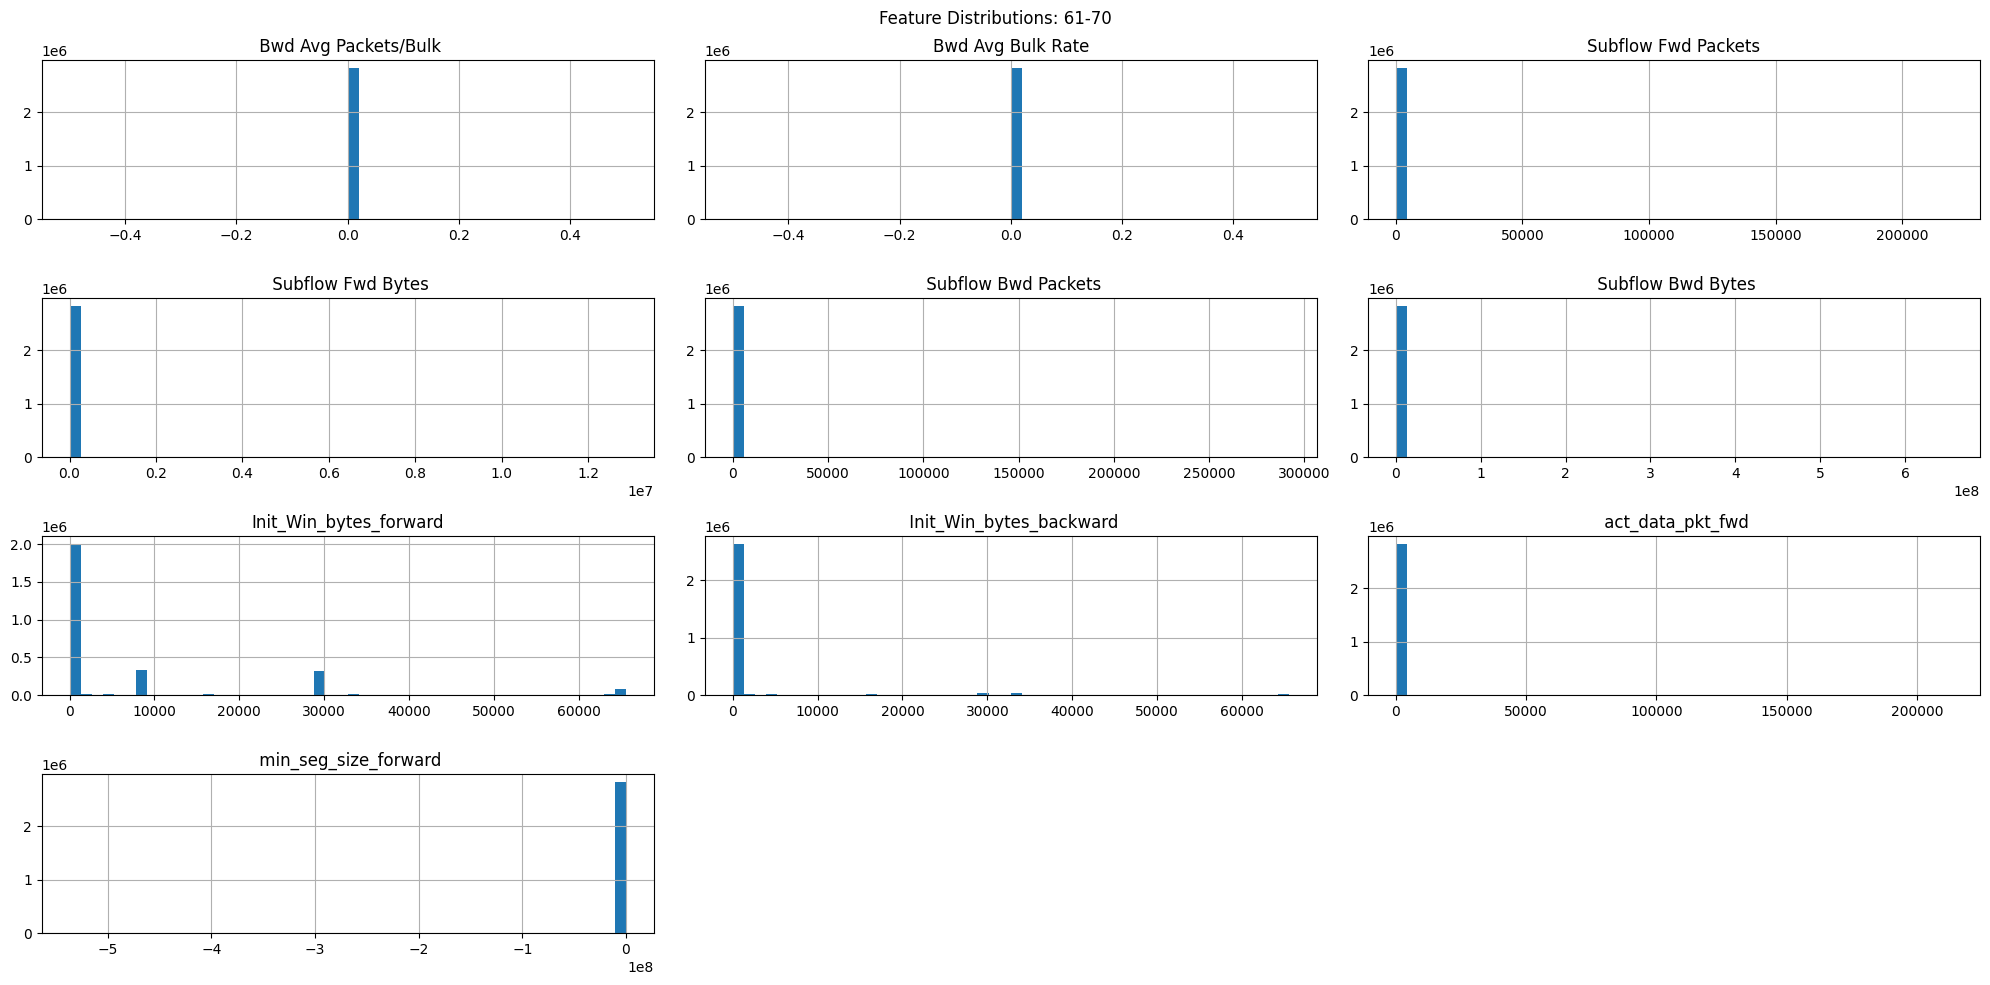

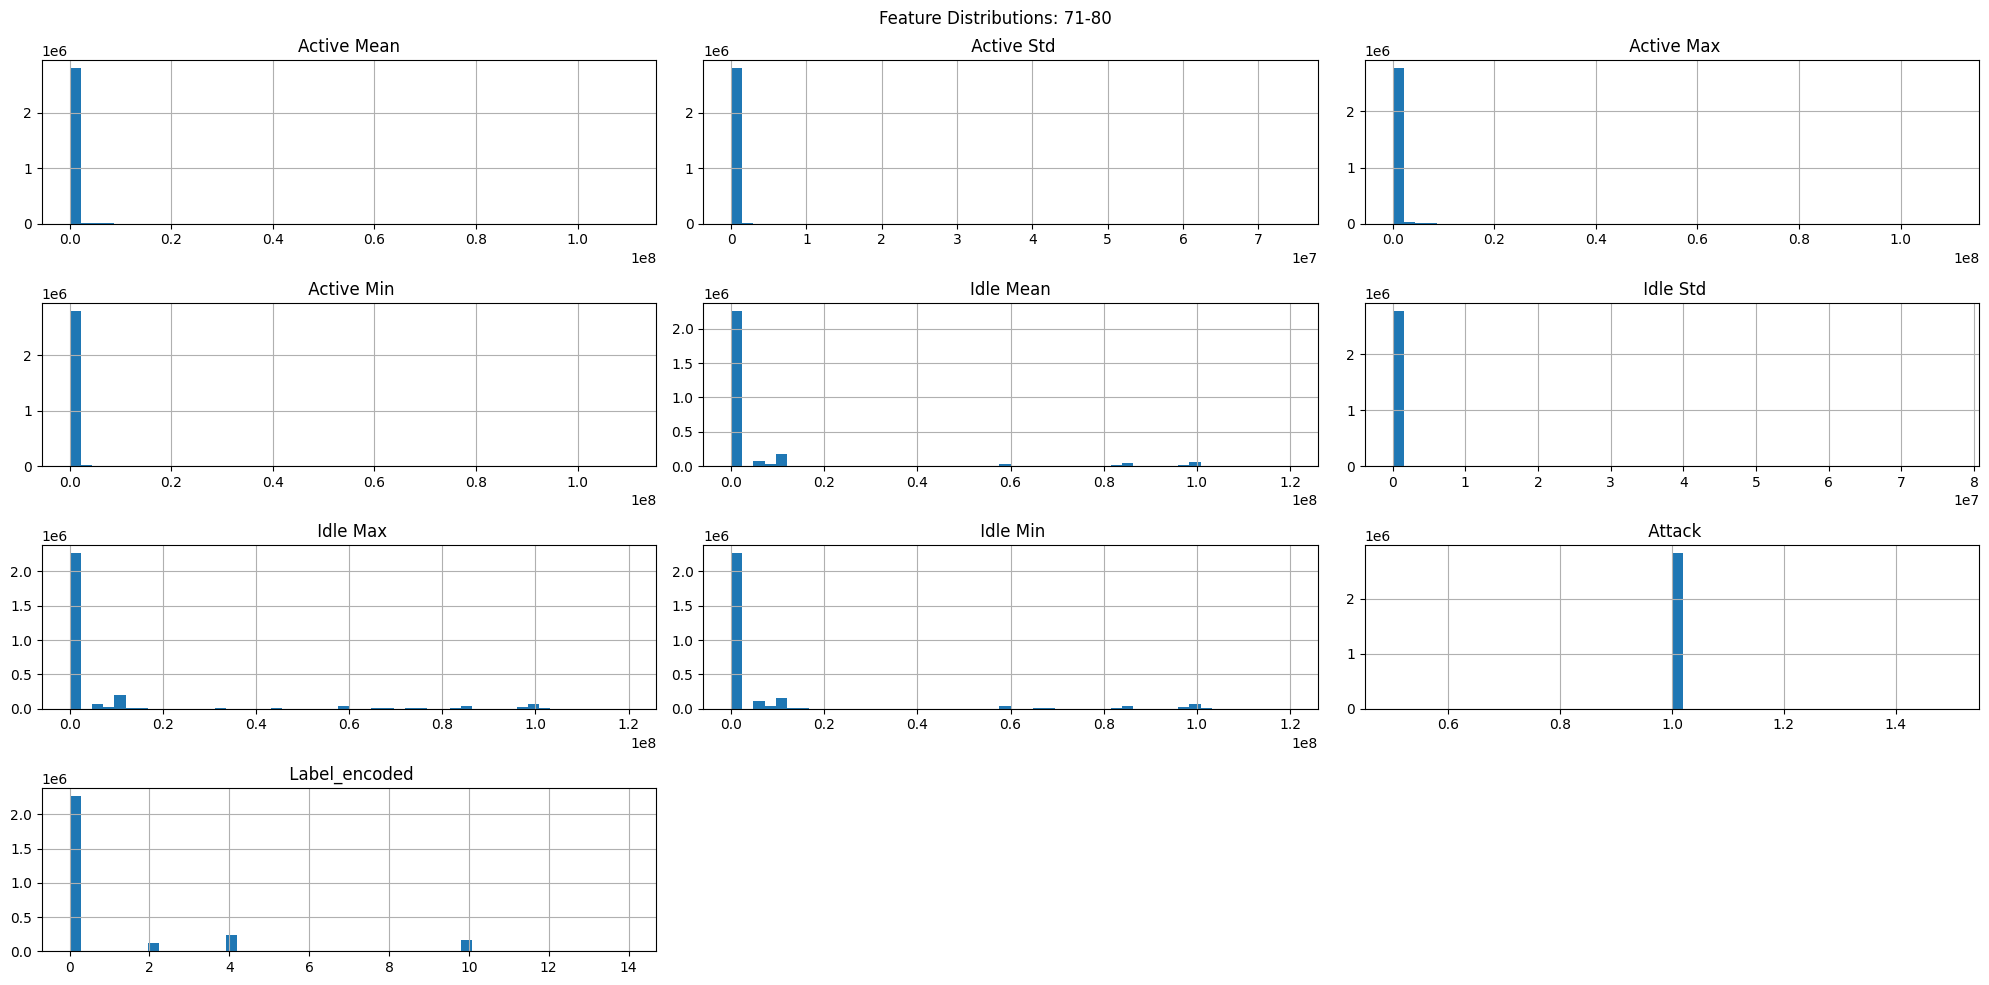

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


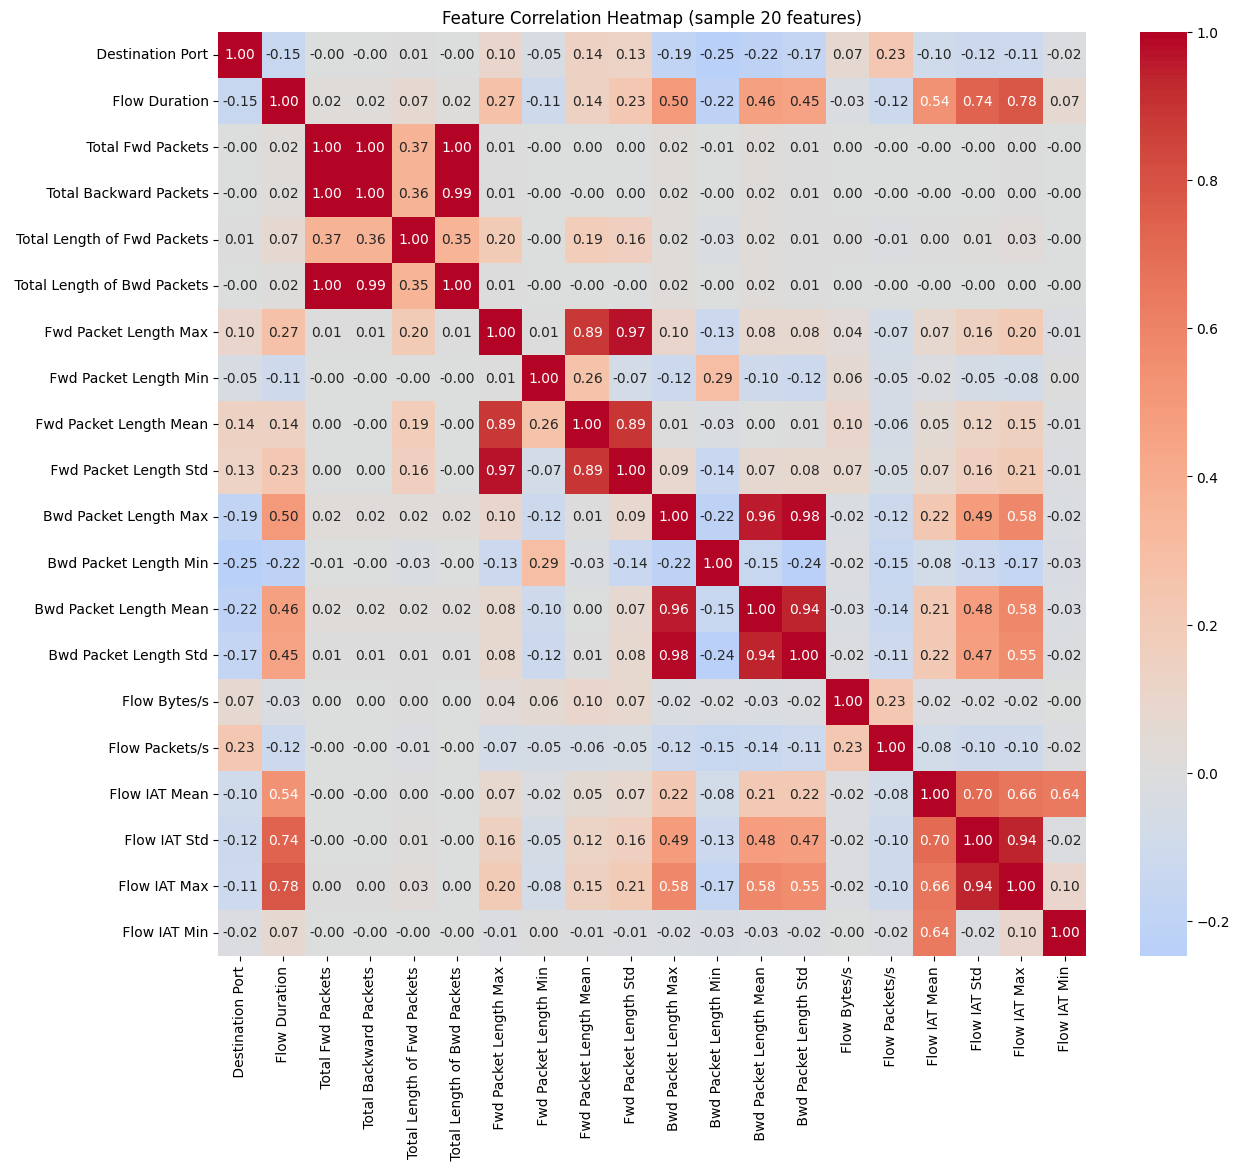

In [9]:
# 📌 Step 5: EDA
# --- Clean numeric features ---
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

# Replace inf/-inf with NaN
data[numeric_cols] = data[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Optionally, fill NaNs with median (or drop rows if too many)
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

# Now plotting in batches of 10
batch_size = 10
for i in range(0, len(numeric_cols), batch_size):
    batch = numeric_cols[i:i+batch_size]
    data[batch].hist(bins=50, figsize=(20,10))
    plt.suptitle(f'Feature Distributions: {i+1}-{i+len(batch)}')
    plt.tight_layout()
    plt.show()


# --- 3️⃣ Correlation heatmaps (sample 20 features for readability) ---
sample_cols = numeric_cols[:20] if len(numeric_cols) > 20 else numeric_cols
corr_matrix = data[sample_cols].corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap (sample 20 features)")
plt.show()

In [8]:
# 📌 Step 6: Feature Selection / Engineering

import numpy as np
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

# --- Step 6a: Clean numeric data ---
# Remove leading/trailing spaces from columns
data.columns = data.columns.str.strip()

# Fix the label column
data['Attack'] = data['Label'].str.strip()  # rename for convenience

# Select numeric columns
numeric_cols = data.select_dtypes(include=[np.number]).columns
data_numeric = data[numeric_cols].copy()

# Replace inf/-inf with NaN and fill NaNs with median
data_numeric.replace([np.inf, -np.inf], np.nan, inplace=True)
data_numeric.fillna(data_numeric.median(), inplace=True)

# --- Step 6b: Remove low-variance features ---
selector = VarianceThreshold(threshold=0.01)
data_numeric_highvar = selector.fit_transform(data_numeric)
selected_features = data_numeric.columns[selector.get_support()]
print(f"High-variance features selected: {len(selected_features)}")

# --- Step 6c: Optional univariate selection (top 30 features) ---
X = data_numeric[selected_features]
y = data['Attack']  # ensure this is clean
kbest = SelectKBest(score_func=f_classif, k=30)
X_new = kbest.fit_transform(X, y)
top_features = X.columns[kbest.get_support()]
print("Top 30 features selected for Stage 1 detector:")
print(top_features)

# --- Top 50 features ---
k50_selector = SelectKBest(score_func=f_classif, k=50)
k50_selector.fit(X, y)
top50_features = X.columns[k50_selector.get_support()].tolist()
print("Top 50 features for Stage 2:")
print(top50_features)

# --- Top 60 features ---
k60_selector = SelectKBest(score_func=f_classif, k=60)
k60_selector.fit(X, y)
top60_features = X.columns[k60_selector.get_support()].tolist()
print("\nTop 60 features for Stage 2:")
print(top60_features)

# --- Step 6d: Scaling for models that need it ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_new)


High-variance features selected: 67


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


Top 30 features selected for Stage 1 detector:
Index(['Flow Duration', 'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean',
       'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Std', 'Bwd IAT Max',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size',
       'Avg Bwd Segment Size', 'Active Mean', 'Active Min', 'Idle Mean',
       'Idle Max', 'Idle Min', 'Label_encoded'],
      dtype='object')


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


Top 50 features for Stage 2:
['Destination Port', 'Flow Duration', 'Total Length of Fwd Packets', 'Fwd Packet Length Min', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio', 'Average Packet Size', 'Avg Bwd Segment Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min', 'Label_encoded']


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw



Top 60 features for Stage 2:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow

In [17]:
# Compute variance for all numeric features
feature_variances = data_numeric.var().sort_values(ascending=False)

# Convert to a table
variance_table = feature_variances.reset_index()
variance_table.columns = ['Feature', 'Variance']

# Display top 30 for readability
print("Top 30 feature variances:")
print(variance_table.head(60))

# Optionally, display full table
print(variance_table)


Top 30 feature variances:
                        Feature      Variance
0                 Flow Duration  1.132574e+15
1                 Fwd IAT Total  1.127335e+15
2                 Bwd IAT Total  8.257930e+14
3                  Flow Bytes/s  6.722124e+14
4                   Fwd IAT Max  6.016796e+14
5                  Flow IAT Max  5.982691e+14
6                      Idle Max  5.937452e+14
7                     Idle Mean  5.583806e+14
8                      Idle Min  5.458493e+14
9           Fwd Header Length.1  4.432228e+14
10            Fwd Header Length  4.432228e+14
11                  Bwd IAT Max  2.944982e+14
12                  Fwd IAT Std  9.291139e+13
13                 Fwd IAT Mean  9.073939e+13
14                 Bwd IAT Mean  7.898227e+13
15                  Fwd IAT Min  7.381278e+13
16                  Bwd IAT Min  6.903920e+13
17                 Flow IAT Std  6.473602e+13
18                  Bwd IAT Std  3.941917e+13
19                     Idle Std  2.118747e+13
20      

In [19]:
# 📌 Stage 1: Lightweight Attack Detection - Model Comparison

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, recall_score
import time

# Features & binary target
top_features_stage1 = [f for f in top_features if f != 'Label_encoded']
data['Attack_binary'] = data['Attack'].apply(lambda x: 0 if x == 'BENIGN' else 1)

X = data[top_features_stage1]
y = data['Attack_binary']

# Scaling for models that need it (Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# --- Dictionary of models to test ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "Random Forest (small)": RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42),
    "LightGBM (small)": lgb.LGBMClassifier(n_estimators=200, max_depth=10, learning_rate=0.1, n_jobs=-1, random_state=42)
}

# Train, predict and evaluate each model
results = []

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    end = time.time()
    
    recall = recall_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results.append({
        "Model": name,
        "Recall": recall,
        "Accuracy": report['accuracy'],
        "Train+Predict Time (s)": round(end-start, 2)
    })
    
# Display comparison table
import pandas as pd
results_df = pd.DataFrame(results)
results_df.sort_values(by="Recall", ascending=False, inplace=True)
print(results_df)


[LightGBM] [Info] Number of positive: 446117, number of negative: 1818477
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.489187 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6509
[LightGBM] [Info] Number of data points in the train set: 2264594, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.196996 -> initscore=-1.405173
[LightGBM] [Info] Start training from score -1.405173
                   Model    Recall  Accuracy  Train+Predict Time (s)
3       LightGBM (small)  0.976750  0.985626                   46.19
1  Random Forest (small)  0.884138  0.976204                  251.65
2            Extra Trees  0.777197  0.950183                   91.16
0    Logistic Regression  0.758440  0.924599                  141.55


Stage2


In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

# --- Filter only attack samples ---
attack_data = data[data['Attack'] != 'BENIGN'].copy()

# --- Encode target ---
le = LabelEncoder()
attack_data['Attack_encoded'] = le.fit_transform(attack_data['Attack'])

# --- Prepare numeric features ---
numeric_cols = attack_data.select_dtypes(include=[np.number]).columns.tolist()
if 'Label_encoded' in numeric_cols:
    numeric_cols.remove('Label_encoded')  # remove previous encoding if present

X = attack_data[numeric_cols]
y = attack_data['Attack_encoded']

# --- Replace inf / -inf with NaN, then impute ---
X.replace([np.inf, -np.inf], np.nan, inplace=True)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)

# --- Top 30 features (from Stage 1) ---
top30_features = X.columns[:30].tolist()  # Or use previous Stage 1 selection
X_stage2_top30 = X_imputed_df[top30_features]

# --- Top 50 features ---
k50_selector = SelectKBest(score_func=f_classif, k=50)
k50_selector.fit(X_imputed_df, y)
top50_features = X_imputed_df.columns[k50_selector.get_support()].tolist()
X_stage2_top50 = X_imputed_df[top50_features]

# --- Top 60 features ---
k60_selector = SelectKBest(score_func=f_classif, k=60)
k60_selector.fit(X_imputed_df, y)
top60_features = X_imputed_df.columns[k60_selector.get_support()].tolist()
X_stage2_top60 = X_imputed_df[top60_features]

# --- Info ---
print(f"Stage 2 dataset shape (top30): {X_stage2_top30.shape}")
print(f"Stage 2 dataset shape (top50): {X_stage2_top50.shape}")
print(f"Stage 2 dataset shape (top60): {X_stage2_top60.shape}")
print(f"Number of attack classes: {len(le.classes_)}")


/tmp/ipykernel_37/4206034510.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.replace([np.inf, -np.inf], np.nan, inplace=True)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [31 32 33 45 49 50 56 57 58 59 60 61 78] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Stage 2 dataset shape (top30): (557646, 30)
Stage 2 dataset shape (top50): (557646, 50)
Stage 2 dataset shape (top60): (557646, 60)
Number of attack classes: 14


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [31 32 33 45 49 50 56 57 58 59 60 61 78] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [14]:
!pip install --upgrade imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 52.6 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.13.0
    Uninstalling imbalanced-learn-0.13.0:
      Successfully uninstalled imbalanced-learn-0.13.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1

In [18]:
# --- Stage 2: Multi-Class Attack Classifier ---
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif

# --- Prepare Data ---
# Filter only attack samples (exclude BENIGN)
attack_data = data[data['Attack'] != 'BENIGN'].copy()

# Encode target
le = LabelEncoder()
attack_data['Attack_encoded'] = le.fit_transform(attack_data['Attack'])

# Numeric columns
numeric_cols = attack_data.select_dtypes(include=[np.number]).columns.tolist()
if 'Label_encoded' in numeric_cols:
    numeric_cols.remove('Label_encoded')

X_all = attack_data[numeric_cols]
y_all = attack_data['Attack_encoded']

# Handle NaNs and infinite values
X_all.replace([np.inf, -np.inf], np.nan, inplace=True)
X_all.fillna(X_all.median(), inplace=True)

# --- Feature selection for top 30 / 50 / 60 ---
def get_top_features(X, y, k):
    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(X, y)
    return X.columns[selector.get_support()].tolist()

top30_features = get_top_features(X_all, y_all, 30)
top50_features = get_top_features(X_all, y_all, 50)
top60_features = get_top_features(X_all, y_all, 60)

feature_sets = {'Top30': top30_features, 'Top50': top50_features, 'Top60': top60_features}

# --- Model classes (we will instantiate fresh models per feature set) ---
model_classes = {
    'LightGBM': LGBMClassifier,
    'RandomForest': RandomForestClassifier,
    'ExtraTrees': ExtraTreesClassifier
}

# --- Train + Evaluate ---
results = []

for fname, features in feature_sets.items():
    print(f"\n=== Feature set: {fname} ({len(features)} features) ===")
    
    X = X_all[features]
    y = y_all
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Standard scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    for mname, ModelClass in model_classes.items():
        print(f"\nTraining {mname}...")
        
        # Instantiate a fresh model
        if mname == 'LightGBM':
            model = ModelClass(class_weight='balanced', random_state=42, n_jobs=-1)
        else:
            model = ModelClass(class_weight='balanced', random_state=42, n_jobs=-1)
        
        # Fit and predict
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        # Evaluation
        report = classification_report(y_test, y_pred, output_dict=True)
        accuracy = report['accuracy']
        
        results.append({
            'Model': mname,
            'Feature_Set': fname,
            'Accuracy': accuracy
        })
        
        print(classification_report(y_test, y_pred))
        
# --- Results summary ---
results_df = pd.DataFrame(results)
print("\n=== Summary ===")
print(results_df)


/tmp/ipykernel_37/1092759968.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_all.replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipykernel_37/1092759968.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_all.fillna(X_all.median(), inplace=True)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [31 32 33 45 49 50 56 57 58 59 60 61 78] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarnin


=== Feature set: Top30 (30 features) ===

Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024930 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3898
[LightGBM] [Info] Number of data points in the train set: 446116, number of used features: 30
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from scor